# KnotTransformer — Phase 2 Training

Trains a single transformer to predict B-spline knot parameterisations across multiple sequence lengths (N ∈ {4, 5}), then evaluates whether it transfers to unseen lengths (N = 6, 7, 8).

---

## How to use this notebook

**Every fresh runtime, run these in order:**

1. Setup → GPU check
2. Setup → Upload code bundle *(only if `/content` is empty)*
3. Setup → Mount Drive
4. Setup → Config
5. Setup → Imports
6. Setup → Load data + build model
7. Setup → Define training functions
8. Setup → GPU patch + smoke test  ← **must show finite numbers, not `nan`**

**Then pick what you want to do:**

| Goal | What to run |
|------|-------------|
| Train original seed (25) | **Train** section |
| Train a new seed | **Select seed** cell → re-run **GPU patch** → **Train** |
| Evaluate on N = 4, 5, 6 | **Evaluate · standard** |
| Test extrapolation to N = 7, 8 | **Evaluate · extrapolation** |
| Compare with thesis hard-test | **Evaluate · hard test** |
| Generate the trajectory plot | **Plot trajectory** |
| Generate the B-spline figure | **B-spline figure** |
| Download everything | **Backup to laptop** |

---

# 1 · Setup

*Run these the first time you connect a runtime, and again after any disconnect.*

## 1.1 · GPU check

Confirms PyTorch sees a GPU. If it doesn't, go to **Runtime → Change runtime type → T4 GPU** (or better).

In [21]:
import torch
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device name:", torch.cuda.get_device_name(0))
    print("VRAM total:", f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️  No GPU detected. Runtime → Change runtime type → T4 GPU")

PyTorch: 2.11.0+cu128
CUDA available: True
Device name: NVIDIA L4
VRAM total: 23.7 GB


## 1.2 · Upload code bundle

Upload `colab_bundle.zip` when prompted. Only needed if `/content` is empty (fresh runtime). The bundle contains:

- `knot_transformer.py` — the model
- `curvature_layer_nd.py`, `curvatureLayer.py` — the differentiable curvature solver
- `generalization_experiment.py` — eval helpers and chordal baseline
- `phase1_generalization.pt` — Phase 1 checkpoint (starting point for Phase 2)
- `dataset_1k.pt` — 1 000-sample training set

In [ ]:
from google.colab import files
import zipfile, os

print("Click 'Choose Files' and select colab_bundle.zip ...")
uploaded = files.upload()
for name in uploaded:
    if name.endswith('.zip'):
        with zipfile.ZipFile(name, 'r') as z:
            z.extractall('/content')
        print(f"Extracted {name}")

for f in ['knot_transformer.py', 'curvature_layer_nd.py',
          'curvatureLayer.py', 'generalization_experiment.py',
          'phase1_generalization.pt', 'dataset_1k.pt']:
    p = f'/content/{f}'
    print(f"  {'✓' if os.path.exists(p) else '✗'}  {f}")

Click 'Choose Files' and select colab_bundle.zip ...


Saving colab_bundle (1).zip to colab_bundle (1).zip
Extracted colab_bundle (1).zip
  ✓  knot_transformer.py
  ✓  curvature_layer_nd.py
  ✓  curvatureLayer.py
  ✓  generalization_experiment.py
  ✓  phase1_generalization.pt
  ✓  dataset_1k.pt


## 1.3 · Mount Drive

Click the auth link when prompted. Checkpoints are saved to `MyDrive/knot_transformer_ckpts/`.

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

CKPT_DIR = '/content/drive/MyDrive/knot_transformer_ckpts'
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(f'{CKPT_DIR}/snapshots', exist_ok=True)
print(f"Saving checkpoints to: {CKPT_DIR}")
print(f"Snapshots subdir     : {CKPT_DIR}/snapshots")

Mounted at /content/drive
Saving checkpoints to: /content/drive/MyDrive/knot_transformer_ckpts
Snapshots subdir     : /content/drive/MyDrive/knot_transformer_ckpts/snapshots


## 1.4 · Config

Training hyperparameters and paths.

> By default, paths point at the **base** `knot_transformer_ckpts/` folder (the original seed 25).
> To train a new seed, run the **Select seed** cell after Setup is complete.

In [ ]:
# ─── Training hyperparameters ─────────────────────────────────────────
TARGET_EPOCHS  = 300
BATCH_SIZE     = 128
LR             = 1e-5
ENERGY_CAP     = 1000.0
EPS_BOUNDARY   = 0.02
GRAD_CLIP      = 1.0
HOLDOUT_EVERY  = 5      # evaluate on held-out N=6 every N epochs
HOLDOUT_N      = 200    # held-out set size during training
SNAPSHOT_EVERY = 25     # copy best checkpoints to snapshots/ every N epochs
SEED           = 20260525

DATA_PT          = '/content/dataset_1k.pt'
PHASE1_PT        = '/content/phase1_generalization.pt'
STATE_PT         = f'{CKPT_DIR}/phase2_state.pt'
BEST_HOLDOUT_PT  = f'{CKPT_DIR}/phase2_best_holdout.pt'
BEST_TRAIN_PT    = f'{CKPT_DIR}/phase2_best_trainloss.pt'
LATEST_PT        = f'{CKPT_DIR}/phase2_latest.pt'   # the most recent epoch
TRAJ_PT          = f'{CKPT_DIR}/phase2_trajectory.json'

print(f"Target epochs : {TARGET_EPOCHS}")
print(f"Batch size    : {BATCH_SIZE}")
print(f"Learning rate : {LR}")
print(f"Checkpoints   : {CKPT_DIR}")

Target epochs : 300
Batch size    : 128
Learning rate : 1e-05
Checkpoints   : /content/drive/MyDrive/knot_transformer_ckpts


## 1.5 · Imports

Imports project modules, picks up the GPU, sets the random seed.

In [ ]:
import sys, time, json
sys.path.insert(0, '/content')

import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

import knot_transformer as kt_mod
import curvature_layer_nd as cl
import curvatureLayer  # backward-compat shim
import generalization_experiment as ge

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# Patch the modules to use the GPU
kt_mod.device = DEVICE
ge.device     = DEVICE

from knot_transformer import (
    KnotTransformer, BSplineDataset, collate_variable_length,
)
from generalization_experiment import gen_random_points

np.random.seed(SEED); torch.manual_seed(SEED)

Using device: cuda


## 1.6 · Load data and build model

Loads the 1k training set, derives the 500-sample held-out N = 6 set from the seed, builds the model + Adam optimizer.

In [ ]:
payload = torch.load(DATA_PT, weights_only=False)
ds = BSplineDataset(payload['pts'], payload['heur'], task='curvature')
print(f"Training samples: {len(ds)}")
ns = [len(h) + 2 for h in payload['heur']]
for n_pts in sorted(set(ns)):
    print(f"  N={n_pts} ({n_pts-2} dof): {ns.count(n_pts)} samples")

# Held-out N=6 set
rng = np.random.default_rng(SEED)
_ = gen_random_points(2000, 4, rng)
_ = gen_random_points(2000, 5, rng)
_ = gen_random_points(500, 4, rng)
_ = gen_random_points(500, 5, rng)
holdout = gen_random_points(500, 6, rng)[:HOLDOUT_N]
print(f"\nHeld-out: {len(holdout)} N=6 samples (4 dof, UNSEEN during training)")

# Model + optimizer
model = KnotTransformer(
    d_model=64, nhead=4,
    num_encoder_layers=3, num_decoder_layers=3,
    dim_feedforward=256, dropout=0.1,
    max_points=10, max_knots=6,
).to(DEVICE)
optim = torch.optim.Adam(model.parameters(), lr=LR)
print(f"\nModel params: {sum(p.numel() for p in model.parameters()):,}")

Training samples: 3187
  N=4 (2 dof): 1628 samples
  N=5 (3 dof): 1559 samples

Held-out: 200 N=6 samples (4 dof, UNSEEN during training)

Model params: 353,793


## 1.7 · Define training and evaluation functions

Defines `train_one_epoch` and `evaluate_holdout_gpu`.

> The smoke test at the bottom of this cell uses the **unpatched** eval — it will print `nan`. That's expected. The next cell (GPU patch) fixes it.

In [ ]:
def rescale_interior(knots, eps=EPS_BOUNDARY):
    return eps + (1.0 - 2.0 * eps) * knots


def train_one_epoch(model, loader, optim):
    model.train()
    epoch_capped = 0.0
    epoch_valid  = 0
    nan_skips    = 0
    raw_energies = []

    for batch in loader:
        points_2d  = batch['points'].to(DEVICE)
        point_mask = batch['point_mask'].to(DEVICE)
        num_knots  = batch['num_knots'].to(DEVICE)

        optim.zero_grad()
        predicted = model(points_2d, point_mask, num_knots)
        B = points_2d.shape[0]

        n_pts_per = (point_mask == False).sum(dim=1)
        groups = {}
        for b in range(B):
            n = int(n_pts_per[b].item())
            groups.setdefault(n, []).append(b)

        batch_energy_sum = []
        batch_n_valid = 0
        for n_pts, idxs in groups.items():
            K = n_pts - 2
            pts_g  = points_2d[idxs, :n_pts]
            pred_g = predicted[idxs, :K]
            interior_g = rescale_interior(pred_g)

            G = len(idxs)
            zeros = torch.zeros(G, 4, dtype=torch.double, device=DEVICE)
            ones  = torch.ones( G, 4, dtype=torch.double, device=DEVICE)
            full_kv = torch.cat([zeros, interior_g, ones], dim=1)
            pts_cl = pts_g.unsqueeze(-1)

            try:
                C   = cl.solve(pts_cl, full_kv)
                eng = cl.global_curvature(C, full_kv, 3, 100)
            except Exception:
                nan_skips += G
                continue

            finite = torch.isfinite(eng)
            nb = int((~finite).sum().item())
            if nb: nan_skips += nb
            n_ok = int(finite.sum().item())
            if n_ok == 0: continue

            eng_ok = eng[finite]
            eng_cap = torch.clamp(eng_ok, max=ENERGY_CAP)
            batch_energy_sum.append(eng_cap.sum())
            batch_n_valid += n_ok
            raw_energies.extend(eng_ok.detach().cpu().tolist())

        if not batch_energy_sum: continue
        loss = torch.stack(batch_energy_sum).sum() / batch_n_valid
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optim.step()
        epoch_capped += float(loss.detach()) * batch_n_valid
        epoch_valid  += batch_n_valid

    capped_mean = epoch_capped / max(epoch_valid, 1)
    raw_med = float(np.median(raw_energies)) if raw_energies else float('nan')
    raw_p99 = float(np.percentile(raw_energies, 99)) if raw_energies else float('nan')
    return capped_mean, raw_med, raw_p99, epoch_valid, nan_skips


# ─── THE FIX: GPU-aware held-out evaluation ──────────────────────────────
def evaluate_holdout_gpu(model, holdout_pts, n_dof=4):
    """Returns (win_rate, median_ratio) on held-out set.

    Unlike ge.evaluate_on_test_set, this function explicitly moves tensors
    to the model's device before predict(). That was the silent bug in v1.
    """
    model.eval()
    kappa_model, kappa_chordal = [], []
    better = valid = 0

    for points_np in holdout_pts:
        chord_knots = ge.chordal_interior_knots(points_np)

        pts_t = torch.tensor(points_np, dtype=torch.double).to(DEVICE)  # ← THE FIX
        with torch.no_grad():
            pred_knots = model.predict(pts_t, num_knots=n_dof)
        pred_knots_np = pred_knots.cpu().numpy()
        pred_eval = ge.rescale_knots_to_interior(pred_knots_np)

        k_m = ge.compute_curvature_batch(points_np, pred_eval)
        k_c = ge.compute_curvature_batch(points_np, chord_knots)
        if np.isnan(k_m) or np.isnan(k_c): continue

        kappa_model.append(k_m)
        kappa_chordal.append(k_c)
        if k_m <= k_c: better += 1
        valid += 1

    if not valid:
        return float('nan'), float('nan')
    win = better / valid
    ratio = float(np.median(kappa_model)) / float(np.median(kappa_chordal))
    return win, ratio


# Smoke-test: prove the eval works on the freshly built (pre-Phase-1) model
test_win, test_ratio = evaluate_holdout_gpu(model, holdout[:20])
print(f"Smoke test on 20 samples (untrained model): "
      f"win={test_win:.3f}, ratio={test_ratio:.4f}")
print("If you see real numbers (not nan), the eval is wired correctly.")

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: nested_from_padded CUDA kernels only support fp32/fp16; falling back to slower generic kernel (Triggered internally at /pytorch/aten/src/ATen/native/nested/cuda/NestedTensorTransformerFunctions.cpp:52.)
  output = torch._nested_tensor_from_mask(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Smoke test on 20 samples (untrained model): win=nan, ratio=nan
If you see real numbers (not nan), the eval is wired correctly.


## 1.8 · GPU patch + smoke test

**Critical step.** Patches `ge.compute_curvature_batch` so it works with GPU tensors.

The smoke test at the bottom **must** print finite numbers (e.g. `win=0.35, ratio=1.23`). If it prints `nan`, stop and re-run this cell before doing anything else.

In [ ]:
import numpy as np
import torch
import curvature_layer_nd as cl
import generalization_experiment as ge

def compute_curvature_batch_gpu(points_np, knots_interior, device=DEVICE):
    """Drop-in replacement for ge.compute_curvature_batch that places
    all solver inputs on the same device as the model."""
    pts_t = (torch.tensor(points_np, dtype=torch.double)
                  .unsqueeze(0).unsqueeze(-1).to(device))
    full_kv = np.concatenate([np.zeros(4), knots_interior, np.ones(4)])
    knots_t = torch.tensor(full_kv, dtype=torch.double).unsqueeze(0).to(device)

    sorted_kv = np.sort(knots_interior)
    if np.any(np.diff(sorted_kv) < 1e-6):
        return float("nan")
    if knots_interior.min() <= 1e-6 or knots_interior.max() >= 1.0 - 1e-6:
        return float("nan")

    try:
        with torch.no_grad():
            C = cl.solve(pts_t, knots_t)
            eng = cl.global_curvature(C, knots_t, 3, 100)
        val = float(eng.item())
        return val if np.isfinite(val) else float("nan")
    except Exception as e:
        # Surface the error during diagnostics — comment out later
        # print(f"solver failed: {e}")
        return float("nan")


def evaluate_holdout_gpu(model, holdout_pts, n_dof=4):
    """Returns (win_rate, median_ratio) on held-out set.

    Unlike ge.evaluate_on_test_set, this function explicitly moves tensors
    to the model's device before predict(). That was the silent bug in v1.
    """
    model.eval()
    kappa_model, kappa_chordal = [], []
    better = valid = 0

    for points_np in holdout_pts:
        chord_knots = ge.chordal_interior_knots(points_np)

        pts_t = torch.tensor(points_np, dtype=torch.double).to(DEVICE)  # ← THE FIX
        with torch.no_grad():
            pred_knots = model.predict(pts_t, num_knots=n_dof)
        pred_knots_np = pred_knots.cpu().numpy()
        pred_eval = ge.rescale_knots_to_interior(pred_knots_np)

        k_m = ge.compute_curvature_batch(points_np, pred_eval)
        k_c = ge.compute_curvature_batch(points_np, chord_knots)
        if np.isnan(k_m) or np.isnan(k_c): continue

        kappa_model.append(k_m)
        kappa_chordal.append(k_c)
        if k_m <= k_c: better += 1
        valid += 1

    if not valid:
        return float('nan'), float('nan')
    win = better / valid
    ratio = float(np.median(kappa_model)) / float(np.median(kappa_chordal))
    return win, ratio


# Override the module-level functions so evaluate_holdout_gpu uses them
ge.compute_curvature_batch = compute_curvature_batch_gpu

# Re-run the smoke test
test_win, test_ratio = evaluate_holdout_gpu(model, holdout[:20])
print(f"\nSmoke test after fix: win={test_win:.3f}, ratio={test_ratio:.4f}")
print("If those are real numbers, you're good to run cell 8.")


Smoke test after fix: win=0.400, ratio=1.4880
If those are real numbers, you're good to run cell 8.


## 1.9 · Diagnostic *(optional)*

Run this any time to confirm which paths are active and what's defined.

Use it whenever you're not sure if Setup completed correctly, or after switching seeds.

In [ ]:
print("Path checks:")
print(f"  STATE_PT        = {STATE_PT}")
print(f"  BEST_HOLDOUT_PT = {BEST_HOLDOUT_PT}")
print(f"  → Seed-26 paths active: {'seed_20260526' in STATE_PT}")

print("\nDefined:")
for name in ['model', 'optim', 'holdout', 'evaluate_holdout_gpu', 'train_one_epoch']:
    print(f"  {'✓' if name in dir() else '✗'}  {name}")

print("\nGPU patch:")
import generalization_experiment as ge
print(f"  Active: {ge.compute_curvature_batch.__module__ == '__main__'}")

Path checks:
  STATE_PT        = /content/drive/MyDrive/knot_transformer_ckpts/phase2_state.pt
  BEST_HOLDOUT_PT = /content/drive/MyDrive/knot_transformer_ckpts/phase2_best_holdout.pt
  → Seed-26 paths active: False

Defined:
  ✓  model
  ✓  optim
  ✓  holdout
  ✓  evaluate_holdout_gpu
  ✓  train_one_epoch

GPU patch:
  Active: True


---

# 2 · Select a different seed *(optional)*

Only run this section if you want to train a **new seed** for multi-seed validation.

**What it does:**
- Redirects all save paths to a per-seed subfolder (`seed_<N>/`)
- Rebuilds the model with fresh random weights
- Re-derives the held-out set from the new seed

**After running it, you MUST re-run section 1.8 (GPU patch + smoke test)** to confirm the eval still works on the freshly-built model.

In [ ]:
# ─── Multi-seed run: change NEW_SEED between sessions ──────────────────
# Session 1:  NEW_SEED = 20260526
# Session 2:  NEW_SEED = 20260527
#
# Each writes to a per-seed subfolder so they don't collide with your
# original 20260525 run.

NEW_SEED = 20260527   # ← change to 20260527 for the second session

import os
SEED_DIR = f'{CKPT_DIR}/seed_{NEW_SEED}'
os.makedirs(f'{SEED_DIR}/snapshots', exist_ok=True)

# Override the global paths used by cell 8
STATE_PT         = f'{SEED_DIR}/phase2_state.pt'
BEST_HOLDOUT_PT  = f'{SEED_DIR}/phase2_best_holdout.pt'
BEST_TRAIN_PT    = f'{SEED_DIR}/phase2_best_trainloss.pt'
LATEST_PT        = f'{SEED_DIR}/phase2_latest.pt'
TRAJ_PT          = f'{SEED_DIR}/phase2_trajectory.json'

# Re-seed everything
import numpy as np, torch
np.random.seed(NEW_SEED)
torch.manual_seed(NEW_SEED)

# Fresh model + fresh optimizer for this seed
model = KnotTransformer(
    d_model=64, nhead=4,
    num_encoder_layers=3, num_decoder_layers=3,
    dim_feedforward=256, dropout=0.1,
    max_points=10, max_knots=6,
).to(DEVICE)
optim = torch.optim.Adam(model.parameters(), lr=LR)

# Re-derive held-out set from the new seed so each run gets its own
rng = np.random.default_rng(NEW_SEED)
_ = gen_random_points(2000, 4, rng); _ = gen_random_points(2000, 5, rng)
_ = gen_random_points(500, 4, rng);  _ = gen_random_points(500, 5, rng)
holdout = gen_random_points(500, 6, rng)[:HOLDOUT_N]

print(f"Seed {NEW_SEED}: ready.  State → {SEED_DIR}")
print(f"Held-out: {len(holdout)} N=6 samples")
print(f"\nNow:")
print(f"  1. Re-paste the GPU-eval patch cell (compute_curvature_batch_gpu)")
print(f"  2. Run smoke test — confirm finite numbers, not nan")
print(f"  3. Run cell 8 (the training cell). It will start fresh from Phase 1.")

Seed 20260527: ready.  State → /content/drive/MyDrive/knot_transformer_ckpts/seed_20260527
Held-out: 200 N=6 samples

Now:
  1. Re-paste the GPU-eval patch cell (compute_curvature_batch_gpu)
  2. Run smoke test — confirm finite numbers, not nan
  3. Run cell 8 (the training cell). It will start fresh from Phase 1.


---

# 3 · Train

Runs Phase 2 energy fine-tuning for `TARGET_EPOCHS` epochs. Saves checkpoints to whichever paths are currently active (base directory or seed-specific folder).

**Behaviour:**
- Resumes automatically if `STATE_PT` exists
- Otherwise starts fresh from the Phase 1 checkpoint
- Persists state, latest, best-by-train, best-by-holdout after every epoch
- Snapshots every 25 epochs to `snapshots/`

**Wall-clock:** ~50 min (A100) · ~100 min (L4) · ~200 min (T4)

**What you should see on the first line:**
- `Fresh start — loading Phase 1 checkpoint`  → new training run
- `Resumed at epoch N/300`  → continuing an existing run

If you see `Resumed at epoch 300/300` when you expected a fresh start, the paths are pointing at a completed run — run **Select seed** first.

In [ ]:
# Resume / fresh start
completed = 0
trajectory = []
best_holdout_ratio = float('inf')
best_train_loss    = float('inf')

if os.path.exists(STATE_PT):
    state = torch.load(STATE_PT, weights_only=False, map_location=DEVICE)
    model.load_state_dict(state['model'])
    optim.load_state_dict(state['opt'])
    completed = state['completed']
    trajectory = state['trajectory']
    best_holdout_ratio = state.get('best_holdout_ratio', float('inf'))
    best_train_loss    = state.get('best_train_loss',    float('inf'))
    print(f"Resumed at epoch {completed}/{TARGET_EPOCHS}")
    print(f"  Best held-out ratio so far: {best_holdout_ratio:.4f}")
    print(f"  Best train loss so far:     {best_train_loss:.4f}")
else:
    print("Fresh start — loading Phase 1 checkpoint")
    model.load_state_dict(torch.load(PHASE1_PT, map_location=DEVICE))

loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True,
                    collate_fn=collate_variable_length)

print(f"\nTraining epochs {completed+1}..{TARGET_EPOCHS}")
print(f"  Batch {BATCH_SIZE}, lr {LR}, energy cap {ENERGY_CAP}")
print(f"  Held-out eval every {HOLDOUT_EVERY} epochs on {HOLDOUT_N}-sample N=6 set")
print(f"  Snapshot every {SNAPSHOT_EVERY} epochs to {CKPT_DIR}/snapshots/")
print('─' * 78)

t0 = time.time()
for ep in range(completed + 1, TARGET_EPOCHS + 1):
    capped, raw_med, raw_p99, nv, nskip = train_one_epoch(model, loader, optim)

    train_tag = ''
    if capped < best_train_loss:
        best_train_loss = capped
        torch.save(model.state_dict(), BEST_TRAIN_PT)
        train_tag = ' [↓train]'

    hr_win, hr_ratio = float('nan'), float('nan')
    holdout_tag = ''
    if ep % HOLDOUT_EVERY == 0 or ep == TARGET_EPOCHS:
        hr_win, hr_ratio = evaluate_holdout_gpu(model, holdout)
        if not np.isnan(hr_ratio) and hr_ratio < best_holdout_ratio:
            best_holdout_ratio = hr_ratio
            torch.save(model.state_dict(), BEST_HOLDOUT_PT)
            holdout_tag = ' [↓holdout]'

    trajectory.append({'epoch': ep, 'train_loss': capped,
                       'raw_median': raw_med, 'raw_p99': raw_p99,
                       'holdout_win': hr_win, 'holdout_ratio': hr_ratio})

    if np.isnan(hr_ratio):
        print(f"Epoch {ep:>4d}/{TARGET_EPOCHS} | "
              f"train κ {capped:>7.2f} med {raw_med:>6.1f}{train_tag}")
    else:
        print(f"Epoch {ep:>4d}/{TARGET_EPOCHS} | "
              f"train κ {capped:>7.2f} med {raw_med:>6.1f} | "
              f"holdout win {hr_win:.3f} ratio {hr_ratio:.4f}"
              f"{train_tag}{holdout_tag}")

    # ── Persist after every epoch ────────────────────────────────────
    torch.save({
        'model':              model.state_dict(),
        'opt':                optim.state_dict(),
        'completed':          ep,
        'trajectory':         trajectory,
        'best_holdout_ratio': best_holdout_ratio,
        'best_train_loss':    best_train_loss,
    }, STATE_PT)
    torch.save(model.state_dict(), LATEST_PT)
    with open(TRAJ_PT, 'w') as f:
        json.dump(trajectory, f, indent=2, default=float)

    # ── Periodic snapshot (so mid-run you have backups) ─────────────
    if ep % SNAPSHOT_EVERY == 0:
        torch.save(model.state_dict(),
                   f'{CKPT_DIR}/snapshots/latest_epoch{ep:04d}.pt')
        if best_holdout_ratio < float('inf'):
            torch.save(torch.load(BEST_HOLDOUT_PT, map_location=DEVICE),
                       f'{CKPT_DIR}/snapshots/best_holdout_through_epoch{ep:04d}.pt')

elapsed = time.time() - t0
print('─' * 78)
if TARGET_EPOCHS - completed > 0:
    print(f"Done in {elapsed/60:.1f} min "
          f"({elapsed/(TARGET_EPOCHS - completed):.1f} s/epoch)")
else:
    print(f"Training already completed all {TARGET_EPOCHS} epochs in {elapsed/60:.1f} min.")
print(f"Best held-out ratio : {best_holdout_ratio:.4f}  → {BEST_HOLDOUT_PT}")
print(f"Best train loss     : {best_train_loss:.4f}  → {BEST_TRAIN_PT}")

Resumed at epoch 300/300
  Best held-out ratio so far: 0.1919
  Best train loss so far:     170.7286

Training epochs 301..300
  Batch 128, lr 1e-05, energy cap 1000.0
  Held-out eval every 5 epochs on 200-sample N=6 set
  Snapshot every 25 epochs to /content/drive/MyDrive/knot_transformer_ckpts/snapshots/
──────────────────────────────────────────────────────────────────────────────
──────────────────────────────────────────────────────────────────────────────
Training already completed all 300 epochs in 0.0 min.
Best held-out ratio : 0.1919  → /content/drive/MyDrive/knot_transformer_ckpts/seed_20260527/phase2_best_holdout.pt
Best train loss     : 170.7286  → /content/drive/MyDrive/knot_transformer_ckpts/seed_20260527/phase2_best_trainloss.pt


In [ ]:
import shutil, os
from google.colab import files

sd = f'{CKPT_DIR}/seed_20260527'
shutil.make_archive('/content/seed27_backup', 'zip', sd)
files.download('/content/seed27_backup.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

# 4 · Plot trajectory

Reads `phase2_trajectory.json` from disk and plots training loss + held-out ratio over epochs. Doesn't need the model in memory — you can run this any time, even during training (re-run to refresh).

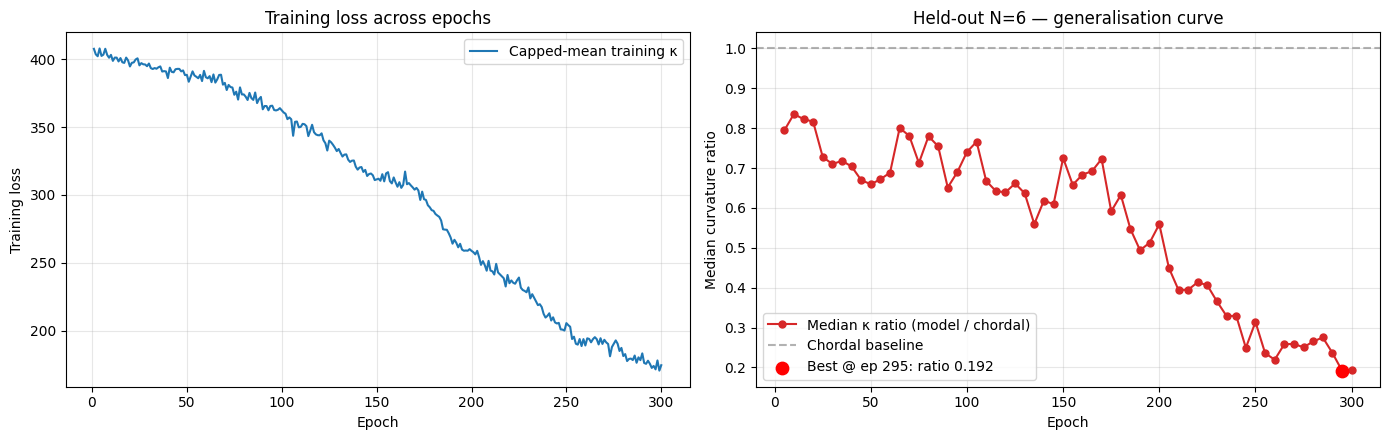


Best held-out ratio so far: 0.1919 at epoch 295


In [ ]:
import matplotlib.pyplot as plt

with open(TRAJ_PT) as f:
    traj = json.load(f)

epochs = [t['epoch'] for t in traj]
train_loss = [t['train_loss'] for t in traj]
ho_epochs    = [t['epoch']         for t in traj if not np.isnan(t['holdout_ratio'])]
ho_ratios    = [t['holdout_ratio'] for t in traj if not np.isnan(t['holdout_ratio'])]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

ax1.plot(epochs, train_loss, color='C0', label='Capped-mean training κ')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Training loss')
ax1.set_title('Training loss across epochs')
ax1.grid(alpha=0.3); ax1.legend()

if ho_ratios:
    ax2.plot(ho_epochs, ho_ratios, 'o-', color='C3', markersize=5,
             label='Median κ ratio (model / chordal)')
    ax2.axhline(1.0, color='gray', linestyle='--', alpha=0.6,
                label='Chordal baseline')
    best_idx = int(np.argmin(ho_ratios))
    ax2.scatter([ho_epochs[best_idx]], [ho_ratios[best_idx]],
                color='red', s=80, zorder=5,
                label=f'Best @ ep {ho_epochs[best_idx]}: ratio {ho_ratios[best_idx]:.3f}')
    ax2.set_title('Held-out N=6 — generalisation curve')
else:
    ax2.text(0.5, 0.5, 'No held-out evaluations yet\n(running, or eval failed)',
             ha='center', va='center', transform=ax2.transAxes)
    ax2.set_title('Held-out N=6 (no data)')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Median curvature ratio')
ax2.grid(alpha=0.3); ax2.legend()

plt.tight_layout()
plt.savefig(f'{CKPT_DIR}/trajectory.png', dpi=120, bbox_inches='tight')
plt.show()
if ho_ratios:
    print(f"\nBest held-out ratio so far: {min(ho_ratios):.4f} "
          f"at epoch {ho_epochs[int(np.argmin(ho_ratios))]}")

---

# 5 · Evaluate · standard (N = 4, 5, 6)

500-sample evaluation on:
- **N = 4, 5** — in-distribution (lengths the model was trained on)
- **N = 6** — one-step-out held-out (the headline result)

Loads `BEST_HOLDOUT_PT`.

In [ ]:
# Pick the strongest checkpoint available
import os
if os.path.exists(BEST_HOLDOUT_PT):
    ckpt = BEST_HOLDOUT_PT
    print(f"Loading BEST-BY-HELD-OUT checkpoint: {ckpt}")
elif os.path.exists(BEST_TRAIN_PT):
    ckpt = BEST_TRAIN_PT
    print(f"⚠️  No held-out checkpoint; using BEST-BY-TRAIN-LOSS: {ckpt}")
else:
    ckpt = LATEST_PT
    print(f"⚠️  Using LATEST checkpoint: {ckpt}")

model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
print()

# Build 500-sample test sets
rng = np.random.default_rng(SEED)
_ = gen_random_points(2000, 4, rng)
_ = gen_random_points(2000, 5, rng)
test_2 = gen_random_points(500, 4, rng)
test_3 = gen_random_points(500, 5, rng)
test_4 = gen_random_points(500, 6, rng)

# Full eval — also GPU-aware
def full_eval_gpu(model, points_list, n_dof):
    model.eval()
    kappa_model, kappa_chordal, knot_l1 = [], [], []
    better = valid = 0
    for points_np in points_list:
        chord_knots = ge.chordal_interior_knots(points_np)
        pts_t = torch.tensor(points_np, dtype=torch.double).to(DEVICE)  # GPU fix
        with torch.no_grad():
            pred = model.predict(pts_t, num_knots=n_dof)
        pred_np = pred.cpu().numpy()
        pred_eval = ge.rescale_knots_to_interior(pred_np)
        k_m = ge.compute_curvature_batch(points_np, pred_eval)
        k_c = ge.compute_curvature_batch(points_np, chord_knots)
        if np.isnan(k_m) or np.isnan(k_c): continue
        kappa_model.append(k_m); kappa_chordal.append(k_c)
        knot_l1.append(float(np.mean(np.abs(pred_eval - chord_knots))))
        if k_m <= k_c: better += 1
        valid += 1
    return {
        'n_dof': n_dof, 'n_valid': valid,
        'acc': better / valid if valid else float('nan'),
        'median_model':   float(np.median(kappa_model))   if kappa_model   else float('nan'),
        'median_chordal': float(np.median(kappa_chordal)) if kappa_chordal else float('nan'),
        'mean_knot_l1':   float(np.mean(knot_l1))         if knot_l1       else float('nan'),
    }

results = {}
print(f"{'split':>10} {'N':>3} {'dof':>4} {'win rate':>14} "
      f"{'med model':>11} {'med chord':>11} {'ratio':>7}")
print('─' * 70)
for ndof, tset, split in [(2, test_2, 'TRAIN-N'), (3, test_3, 'TRAIN-N'),
                          (4, test_4, 'HELD-OUT')]:
    r = full_eval_gpu(model, tset, n_dof=ndof)
    nb = int(round(r['acc'] * r['n_valid']))
    ratio = r['median_model'] / r['median_chordal'] if r['median_chordal'] else float('nan')
    print(f"{split:>10} {ndof+2:>3} {ndof:>4}   "
          f"{r['acc']:.3f} ({nb:>3}/{r['n_valid']:>3})  "
          f"{r['median_model']:>10.2f}  {r['median_chordal']:>10.2f}  "
          f"{ratio:>7.4f}")
    results[f'dof{ndof}'] = r

with open(f'{CKPT_DIR}/final_results.json', 'w') as f:
    json.dump(results, f, indent=2, default=float)
print(f"\nWrote {CKPT_DIR}/final_results.json")

Loading BEST-BY-HELD-OUT checkpoint: /content/drive/MyDrive/knot_transformer_ckpts/seed_20260527/phase2_best_holdout.pt

     split   N  dof       win rate   med model   med chord   ratio
──────────────────────────────────────────────────────────────────────


KeyboardInterrupt: 

---

# 6 · Evaluate · extrapolation (N = 6, 7, 8)

Tests how well the model transfers to sequence lengths *beyond* its training distribution.

| N | dof | Distance from training | Notes |
|---|-----|-----------------------|-------|
| 6 | 4 | One step out | The standard held-out result |
| 7 | 5 | Two steps out | Far held-out |
| 8 | 6 | Three steps out | Far held-out, **activates query slots that never trained** |

The `degenerate` count in the output is the canary — if it's high at N = 8 specifically, that's a clean signal the unused query slots are producing pathological knots.

In [ ]:
# ─── N=7 and N=8 extrapolation test ───────────────────────────────────
# Tests the model on sequence lengths it never saw during training.
# Training distribution: N∈{4,5}. Test: N=6 (one step out), N=7 (two
# steps out), N=8 (three steps out, also activates unused query slots).

import numpy as np
import torch
import json
import os

# Load whichever checkpoint BEST_HOLDOUT_PT points at
ckpt_path = BEST_HOLDOUT_PT
if not os.path.exists(ckpt_path):
    ckpt_path = f'{CKPT_DIR}/phase2_best_holdout.pt'  # fall back to original
print(f"Loaded: {ckpt_path}")
model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
model.eval()


def eval_at_n(model, n_points, n_samples=500, seed=99999):
    """Evaluate on n_samples random sequences of length n_points."""
    n_dof = n_points - 2
    rng = np.random.default_rng(seed + n_points)
    test_set = [rng.uniform(-0.5, 0.5, (n_points, 2)) for _ in range(n_samples)]

    kappa_model, kappa_chordal = [], []
    better = valid = pred_fail = chord_fail = degenerate = 0

    for points_np in test_set:
        chord_knots = ge.chordal_interior_knots(points_np)

        pts_t = torch.tensor(points_np, dtype=torch.double).to(DEVICE)
        try:
            with torch.no_grad():
                pred = model.predict(pts_t, num_knots=n_dof)
            pred_np = pred.cpu().numpy()
        except Exception:
            pred_fail += 1
            continue

        sorted_pred = np.sort(pred_np)
        if np.any(np.diff(sorted_pred) < 1e-4):
            degenerate += 1
            continue

        pred_eval = ge.rescale_knots_to_interior(pred_np)
        k_m = ge.compute_curvature_batch(points_np, pred_eval)
        k_c = ge.compute_curvature_batch(points_np, chord_knots)

        if np.isnan(k_m): pred_fail += 1
        if np.isnan(k_c): chord_fail += 1
        if np.isnan(k_m) or np.isnan(k_c): continue

        kappa_model.append(k_m)
        kappa_chordal.append(k_c)
        if k_m <= k_c: better += 1
        valid += 1

    return {
        'n_points': n_points, 'n_dof': n_dof, 'n_total': n_samples,
        'n_valid': valid, 'pred_fail': pred_fail,
        'chord_fail': chord_fail, 'degenerate': degenerate,
        'win_rate':       better / valid if valid else float('nan'),
        'median_model':   float(np.median(kappa_model))   if kappa_model   else float('nan'),
        'median_chordal': float(np.median(kappa_chordal)) if kappa_chordal else float('nan'),
        'ratio':          (float(np.median(kappa_model)) / float(np.median(kappa_chordal)))
                          if kappa_model and kappa_chordal else float('nan'),
    }


print("\nTraining distribution: N∈{4, 5}")
print("Testing extrapolation ...\n")

results = {}
for N in [6, 7, 8]:
    print(f"  Evaluating N={N} (dof={N-2}) ...")
    r = eval_at_n(model, N, n_samples=500)
    results[f'N{N}'] = r
    print(f"    valid: {r['n_valid']}/500   pred_fail: {r['pred_fail']}   "
          f"degenerate: {r['degenerate']}")


print("\n" + "=" * 82)
print("EXTRAPOLATION RESULTS")
print("=" * 82)
print(f"{'N':>3} {'dof':>4} {'split':>15} {'valid':>9} {'win rate':>14} "
      f"{'med model':>11} {'med chord':>11} {'ratio':>8}")
print("─" * 82)

for N in [6, 7, 8]:
    r = results[f'N{N}']
    split = "HELD-OUT" if N == 6 else "FAR HELD-OUT"
    if r['n_valid'] == 0:
        print(f"{N:>3} {r['n_dof']:>4} {split:>15}  {'0/500':>9}   "
              f"{'— ALL FAILED —':>30}")
        continue
    nb = int(round(r['win_rate'] * r['n_valid']))
    print(f"{N:>3} {r['n_dof']:>4} {split:>15} {r['n_valid']:>4}/500   "
          f"{r['win_rate']:.3f} ({nb:>3}/{r['n_valid']:>3})  "
          f"{r['median_model']:>10.2f}  {r['median_chordal']:>10.2f}  "
          f"{r['ratio']:>8.4f}")

out_path = f'{CKPT_DIR}/extrapolation_results.json'
with open(out_path, 'w') as f:
    json.dump(results, f, indent=2, default=float)
print(f"\nSaved {out_path}")


Loaded: /content/drive/MyDrive/knot_transformer_ckpts/seed_20260527/phase2_best_holdout.pt

Training distribution: N∈{4, 5}
Testing extrapolation ...

  Evaluating N=6 (dof=4) ...
    valid: 500/500   pred_fail: 0   degenerate: 0
  Evaluating N=7 (dof=5) ...
    valid: 500/500   pred_fail: 0   degenerate: 0
  Evaluating N=8 (dof=6) ...
    valid: 500/500   pred_fail: 0   degenerate: 0

EXTRAPOLATION RESULTS
  N  dof           split     valid       win rate   med model   med chord    ratio
──────────────────────────────────────────────────────────────────────────────────
  6    4        HELD-OUT  500/500   0.680 (340/500)      122.73      401.42    0.3057
  7    5    FAR HELD-OUT  500/500   0.678 (339/500)      183.29      476.75    0.3845
  8    6    FAR HELD-OUT  500/500   0.674 (337/500)      242.92      573.88    0.4233

Saved /content/drive/MyDrive/knot_transformer_ckpts/extrapolation_results.json


---

# 7 · Evaluate · hard test (κ > 1000)

Filters to high-curvature samples — comparable to thesis Table 6.9.

This is where the chordal heuristic struggles most (point sets with tight bends), so it's the most demanding test for the model.

In [20]:
# ─── Hard-test across all three seeds ─────────────────────────────────
# Reuses the hard_sets already generated — don't regenerate them.
# Just swaps which checkpoint is loaded for each seed.

import json
import numpy as np

ALL_SEEDS = [20260525, 20260526, 20260527]
all_hard = {}

for seed in ALL_SEEDS:
    # Point at the right checkpoint for each seed
    if seed == 20260525:
        ckpt = f'{CKPT_DIR}/phase2_best_holdout.pt'          # original run
    else:
        ckpt = f'{CKPT_DIR}/seed_{seed}/phase2_best_holdout.pt'

    if not os.path.exists(ckpt):
        print(f"Skipping seed {seed} — no checkpoint at {ckpt}")
        continue

    print(f"\n=== Seed {seed} ===")
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    model.eval()

    seed_results = {}
    for n_dof in (2, 3, 4):
        if not hard_sets[n_dof]:
            print(f"  No hard samples at {n_dof} dof — skipping")
            continue
        r = full_eval_gpu(model, hard_sets[n_dof], n_dof=n_dof)
        nb = int(round(r['acc'] * r['n_valid']))
        ratio = (r['median_model'] / r['median_chordal']
                 if r['median_chordal'] else float('nan'))
        split = "TRAIN-N" if n_dof in (2, 3) else "HELD-OUT"
        print(f"  [{split}] N={n_dof+2} ({n_dof} dof): "
              f"win {r['acc']:.3f} ({nb}/{r['n_valid']})  ratio {ratio:.4f}")
        seed_results[n_dof] = r

    all_hard[seed] = seed_results

# Save
with open(f'{CKPT_DIR}/hard_test_all_seeds.json', 'w') as f:
    json.dump(all_hard, f, indent=2, default=float)
print(f"\nSaved hard_test_all_seeds.json")

# Mean ± std across seeds
print("\n" + "=" * 65)
print("HARD-TEST SUMMARY — mean ± std across 3 seeds")
print("=" * 65)
print(f"{'split':>10} {'N':>3} {'dof':>4}   {'win rate':>20}   {'ratio':>20}")
print("─" * 65)
for n_dof in (2, 3, 4):
    wins   = [all_hard[s][n_dof]['acc']
              for s in all_hard if n_dof in all_hard[s]]
    ratios = [all_hard[s][n_dof]['median_model'] / all_hard[s][n_dof]['median_chordal']
              for s in all_hard if n_dof in all_hard[s]]
    if not wins:
        continue
    split = "TRAIN-N" if n_dof in (2, 3) else "HELD-OUT"
    w_std = np.std(wins,   ddof=1) if len(wins)   > 1 else 0.0
    r_std = np.std(ratios, ddof=1) if len(ratios) > 1 else 0.0
    print(f"{split:>10} {n_dof+2:>3} {n_dof:>4}   "
          f"{np.mean(wins):.3f} ± {w_std:.3f} ({len(wins)} seeds)   "
          f"{np.mean(ratios):.4f} ± {r_std:.4f}")


=== Seed 20260525 ===
  [TRAIN-N] N=4 (2 dof): win 0.934 (467/500)  ratio 0.0190
  [TRAIN-N] N=5 (3 dof): win 0.928 (464/500)  ratio 0.0582
  [HELD-OUT] N=6 (4 dof): win 0.908 (454/500)  ratio 0.0560

=== Seed 20260526 ===
  [TRAIN-N] N=4 (2 dof): win 0.926 (463/500)  ratio 0.0295
  [TRAIN-N] N=5 (3 dof): win 0.902 (451/500)  ratio 0.0534
  [HELD-OUT] N=6 (4 dof): win 0.918 (459/500)  ratio 0.0513

=== Seed 20260527 ===
  [TRAIN-N] N=4 (2 dof): win 0.942 (471/500)  ratio 0.0135
  [TRAIN-N] N=5 (3 dof): win 0.916 (458/500)  ratio 0.0548
  [HELD-OUT] N=6 (4 dof): win 0.886 (443/500)  ratio 0.0537

Saved hard_test_all_seeds.json

HARD-TEST SUMMARY — mean ± std across 3 seeds
     split   N  dof               win rate                  ratio
─────────────────────────────────────────────────────────────────
   TRAIN-N   4    2   0.934 ± 0.008 (3 seeds)   0.0207 ± 0.0081
   TRAIN-N   5    3   0.915 ± 0.013 (3 seeds)   0.0555 ± 0.0025
  HELD-OUT   6    4   0.904 ± 0.016 (3 seeds)   0.0537 ± 0

In [ ]:
# ─── Multi-length evaluation across N=4,5,6,7,8 for all three seeds ───
# N=4 and N=5 are in-distribution (trained on these).
# N=6 is the primary held-out length.
# N=7 and N=8 are far held-out — never seen during training,
# and N=8 uses decoder query slots the model never used during training.

import json
import numpy as np

N_VALUES   = [4, 5, 6, 7, 8]
TEST_SIZE  = 500
ALL_SEEDS  = [20260525, 20260526, 20260527]

# Build one shared test set per N, using a seed separate from training
test_rng = np.random.default_rng(99999)
test_sets = {}
for N in N_VALUES:
    test_sets[N] = [test_rng.uniform(-0.5, 0.5, (N, 2))
                    for _ in range(TEST_SIZE)]
print(f"Built test sets: {TEST_SIZE} samples each at N = {N_VALUES}\n")

all_results = {}   # all_results[seed][N] = result dict

for seed in ALL_SEEDS:
    if seed == 20260525:
        ckpt = f'{CKPT_DIR}/phase2_best_holdout.pt'
    else:
        ckpt = f'{CKPT_DIR}/seed_{seed}/phase2_best_holdout.pt'

    if not os.path.exists(ckpt):
        print(f"Skipping seed {seed} — no checkpoint")
        continue

    print(f"=== Seed {seed} ===")
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    model.eval()

    seed_results = {}
    for N in N_VALUES:
        n_dof = N - 2
        r = full_eval_gpu(model, test_sets[N], n_dof=n_dof)
        nb = int(round(r['acc'] * r['n_valid']))
        ratio = (r['median_model'] / r['median_chordal']
                 if r['median_chordal'] else float('nan'))
        split = ("TRAIN-N"    if N in (4, 5) else
                 "HELD-OUT"   if N == 6      else
                 "FAR HELD-OUT")
        print(f"  {split:>13} N={N} ({n_dof} dof): "
              f"win {r['acc']:.3f} ({nb}/{r['n_valid']})  ratio {ratio:.4f}")
        seed_results[N] = r

    all_results[seed] = seed_results
    print()

# Save raw results
with open(f'{CKPT_DIR}/multi_length_all_seeds.json', 'w') as f:
    json.dump(all_results, f, indent=2, default=float)
print("Saved multi_length_all_seeds.json\n")

# Mean ± std across seeds
print("=" * 70)
print("MULTI-LENGTH SUMMARY — mean ± std across 3 seeds")
print("=" * 70)
print(f"{'N':>3} {'dof':>4} {'split':>14}   {'win rate':>20}   {'ratio':>20}")
print("─" * 70)
for N in N_VALUES:
    n_dof = N - 2
    wins   = [all_results[s][N]['acc']
              for s in all_results if N in all_results[s]]
    ratios = [all_results[s][N]['median_model'] / all_results[s][N]['median_chordal']
              for s in all_results if N in all_results[s]]
    if not wins:
        continue
    split = ("TRAIN-N"    if N in (4, 5) else
             "HELD-OUT"   if N == 6      else
             "FAR HELD-OUT")
    w_std = np.std(wins,   ddof=1) if len(wins)   > 1 else 0.0
    r_std = np.std(ratios, ddof=1) if len(ratios) > 1 else 0.0
    print(f"{N:>3} {n_dof:>4} {split:>14}   "
          f"{np.mean(wins):.3f} ± {w_std:.3f} ({len(wins)} seeds)   "
          f"{np.mean(ratios):.4f} ± {r_std:.4f}")

In [ ]:
# ─── Hard-test evaluation — N=6, chordal κ > threshold ──────────────────
# Comparable to thesis Table 6.9 which tests on κ > 1000 samples only.
# Generates extra raw samples until we have N_TARGET that pass the filter.

import numpy as np
import torch

THRESHOLD = 1000.0      # thesis threshold for the "hard" test set
N_TARGET  = 500         # how many filtered samples we want
N_MAX     = 5000        # safety cap on how many raw samples we'll try

# Use a different seed than the original test sets so this is genuinely new data
hard_rng = np.random.default_rng(20260601)

# Load best-by-held-out checkpoint
model.load_state_dict(torch.load(BEST_HOLDOUT_PT, map_location=DEVICE))
model.eval()
print(f"Loaded {BEST_HOLDOUT_PT}\n")

print(f"Generating N=6 samples and filtering to chord κ > {THRESHOLD} ...")
hard_pts = []
n_tried = 0
n_kept_by_dof = {2: 0, 3: 0, 4: 0}

# We want hard samples at all three N values for a complete table
hard_sets = {2: [], 3: [], 4: []}

for n_dof in (2, 3, 4):
    N = n_dof + 2
    tried = 0
    while len(hard_sets[n_dof]) < N_TARGET and tried < N_MAX:
        pts = hard_rng.uniform(-0.5, 0.5, (N, 2))
        chord = ge.chordal_interior_knots(pts)
        kappa = ge.compute_curvature_batch(pts, chord)
        tried += 1
        if np.isfinite(kappa) and kappa > THRESHOLD:
            hard_sets[n_dof].append(pts)
    print(f"  N={N} ({n_dof} dof): kept {len(hard_sets[n_dof])}/{tried}")

# Evaluate on each hard set
print(f"\n{'split':>10} {'N':>3} {'dof':>4} {'win rate':>14} "
      f"{'med model':>11} {'med chord':>11} {'ratio':>7}")
print("─" * 70)

hard_results = {}
for n_dof in (2, 3, 4):
    if not hard_sets[n_dof]:
        print(f"  No hard samples at {n_dof} dof — skipping")
        continue

    # Use the GPU-aware full_eval function from cell 10
    r = full_eval_gpu(model, hard_sets[n_dof], n_dof=n_dof)
    nb = int(round(r['acc'] * r['n_valid']))
    ratio = r['median_model'] / r['median_chordal'] if r['median_chordal'] else float('nan')
    split = "TRAIN-N" if n_dof in (2, 3) else "HELD-OUT"

    print(f"{split:>10} {n_dof+2:>3} {n_dof:>4}   "
          f"{r['acc']:.3f} ({nb:>3}/{r['n_valid']:>3})  "
          f"{r['median_model']:>10.2f}  {r['median_chordal']:>10.2f}  "
          f"{ratio:>7.4f}")
    hard_results[f'dof{n_dof}'] = r

import json
with open(f'{CKPT_DIR}/hard_test_results.json', 'w') as f:
    json.dump(hard_results, f, indent=2, default=float)
print(f"\nWrote {CKPT_DIR}/hard_test_results.json")

Loaded /content/drive/MyDrive/knot_transformer_ckpts/seed_20260527/phase2_best_holdout.pt

Generating N=6 samples and filtering to chord κ > 1000.0 ...
  N=4 (2 dof): kept 500/2875
  N=5 (3 dof): kept 500/2353
  N=6 (4 dof): kept 500/1877

     split   N  dof       win rate   med model   med chord   ratio
──────────────────────────────────────────────────────────────────────
   TRAIN-N   4    2   0.942 (471/500)       32.71     2417.51   0.0135
   TRAIN-N   5    3   0.916 (458/500)      120.16     2191.57   0.0548
  HELD-OUT   6    4   0.886 (443/500)      136.03     2532.30   0.0537

Wrote /content/drive/MyDrive/knot_transformer_ckpts/hard_test_results.json


In [ ]:
import json
with open(f'{CKPT_DIR}/seed_20260527/phase2_trajectory.json') as f:
    traj = json.load(f)
ho = [(t['epoch'], t['holdout_win'], t['holdout_ratio']) for t in traj
      if t['holdout_ratio'] == t['holdout_ratio']]
best = min(ho, key=lambda x: x[2])
print(f"Seed 27 best: epoch {best[0]}, win {best[1]:.3f}, ratio {best[2]:.4f}")

Seed 27 best: epoch 295, win 0.705, ratio 0.1919


---

# 8 · B-spline figure

Single-sample side-by-side comparison: chordal heuristic vs transformer, on a held-out N = 6 sample where the transformer wins by the largest margin.

The cell scans the first 50 held-out samples, picks the one with the biggest curvature reduction, and produces a publication-quality side-by-side plot.

In [ ]:
# ─── Option A — single-sample B-spline comparison at N=6 (v2) ───────────
# Uses de_boor for curve evaluation, finds a sample where the transformer
# actually wins (instead of the arbitrary sample 7 which was pathological).

import numpy as np
import torch
import matplotlib.pyplot as plt
import curvature_layer_nd as cl
import generalization_experiment as ge

# Make sure cl's internal device variable matches our DEVICE
cl.device = DEVICE

# Load best checkpoint, rebuild held-out test set
model.load_state_dict(torch.load(BEST_HOLDOUT_PT, map_location=DEVICE))
model.eval()
rng = np.random.default_rng(SEED)
_ = ge.gen_random_points(2000, 4, rng); _ = ge.gen_random_points(2000, 5, rng)
_ = ge.gen_random_points(500, 4, rng);  _ = ge.gen_random_points(500, 5, rng)
test_4dof = ge.gen_random_points(500, 6, rng)


# ─── Curve evaluator using de_boor ─────────────────────────────────────
def evaluate_bspline(points_np, interior_knots, n_eval=400):
    """Returns (curve_xy ndarray, total_curvature) for the clamped cubic B-spline."""
    full_kv_np = np.concatenate([np.zeros(4), interior_knots, np.ones(4)])
    pts_t   = torch.tensor(points_np, dtype=torch.double).unsqueeze(0).unsqueeze(-1).to(DEVICE)
    knots_t = torch.tensor(full_kv_np, dtype=torch.double).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        # Solve for control points
        C = cl.solve(pts_t, knots_t)           # (1, n_ctrl, 2, 1)
        # Total curvature
        eng = cl.global_curvature(C, knots_t, 3, 100)
        # Sample the curve densely
        t_samples = torch.linspace(0.0, 1.0, n_eval, dtype=torch.double,
                                   device=DEVICE).clamp(1e-6, 1 - 1e-6)
        # de_boor evaluates one parameter at a time; loop
        curve_pts = []
        for t_val in t_samples:
            t_b = t_val.unsqueeze(0)           # (1,)
            pt  = cl.de_boor(knots_t, t_b, C, 3)   # (1, 2, 1)
            curve_pts.append(pt.squeeze(0).squeeze(-1).cpu().numpy())

    return np.stack(curve_pts, axis=0), float(eng.item())


# ─── Find a sample where the transformer wins clearly ──────────────────
print("Scanning held-out samples for a clean comparison ...")
candidates = []
for i in range(50):
    p = test_4dof[i]
    ck = ge.chordal_interior_knots(p)
    pts_t = torch.tensor(p, dtype=torch.double).to(DEVICE)
    with torch.no_grad():
        pred = ge.rescale_knots_to_interior(
            model.predict(pts_t, num_knots=4).cpu().numpy())
    k_c = ge.compute_curvature_batch(p, ck)
    k_m = ge.compute_curvature_batch(p, pred)
    if np.isfinite(k_c) and np.isfinite(k_m) and k_c > 50:  # skip trivial cases
        candidates.append((i, k_c, k_m, k_m / k_c))

# Sort by ratio (smallest = transformer wins biggest)
candidates.sort(key=lambda x: x[3])
print("\nTop 5 transformer wins (biggest reduction in curvature):")
for i, kc, km, r in candidates[:5]:
    print(f"  sample {i:>3d}: chord κ {kc:>8.2f}  model κ {km:>8.2f}  ratio {r:.3f}")
print("\nTop 5 transformer losses (where chordal wins instead):")
for i, kc, km, r in candidates[-5:]:
    print(f"  sample {i:>3d}: chord κ {kc:>8.2f}  model κ {km:>8.2f}  ratio {r:.3f}")

# Pick the biggest-win sample
SAMPLE_IDX = candidates[0][0]
print(f"\n→ Using sample {SAMPLE_IDX} for the figure (transformer's best case)")


# ─── Build both curves ──────────────────────────────────────────────────
points_np = test_4dof[SAMPLE_IDX]
chord_knots = ge.chordal_interior_knots(points_np)
pts_t = torch.tensor(points_np, dtype=torch.double).to(DEVICE)
with torch.no_grad():
    pred_raw = model.predict(pts_t, num_knots=4).cpu().numpy()
pred_knots = ge.rescale_knots_to_interior(pred_raw)

print(f"\nChordal knots     : {chord_knots}")
print(f"Transformer knots : {pred_knots}")

curve_chord, kappa_chord = evaluate_bspline(points_np, chord_knots)
curve_model, kappa_model = evaluate_bspline(points_np, pred_knots)
print(f"\nChordal κ     : {kappa_chord:.2f}")
print(f"Transformer κ : {kappa_model:.2f}")
print(f"Ratio         : {kappa_model/kappa_chord:.3f}")


# ─── Plot side-by-side ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, curve, kappa, knots, title, color in [
    (axes[0], curve_chord, kappa_chord, chord_knots, 'Chordal heuristic',     'C0'),
    (axes[1], curve_model, kappa_model, pred_knots, 'Transformer (this work)', 'C3'),
]:
    ax.plot(curve[:, 0], curve[:, 1], color=color, lw=2.5, alpha=0.85,
            label='B-spline')
    ax.scatter(points_np[:, 0], points_np[:, 1],
               color='black', s=70, zorder=5, label='Interpolation points')
    ax.set_aspect('equal')
    ax.grid(alpha=0.3)
    knots_str = '[' + ', '.join(f'{k:.3f}' for k in knots) + ']'
    ax.set_title(f"{title}\nκ = {kappa:.2f}    knots = {knots_str}", fontsize=11)
    ax.legend(loc='best', fontsize=9)

plt.suptitle(f"B-spline interpolation, N=6 (held-out), sample #{SAMPLE_IDX}",
             fontsize=13, y=1.02)
plt.tight_layout()

out_path = f'{CKPT_DIR}/bspline_sample_{SAMPLE_IDX}.png'
plt.savefig(out_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"\nSaved {out_path}")


---

# 9 · Backup to laptop

Bundles all important artifacts into a single zip and downloads it. Run this any time — especially before letting Colab disconnect.

Includes:
- Best-by-holdout checkpoint
- Best-by-train-loss checkpoint
- Latest checkpoint
- Trajectory JSON
- Trajectory plot PNG
- Final results JSON

In [22]:
from google.colab import files
import shutil, os

# Bundle everything important into one downloadable zip
to_save = [
    BEST_HOLDOUT_PT,            # the model
    BEST_TRAIN_PT,
    LATEST_PT,
    TRAJ_PT,                    # the trajectory
    f'{CKPT_DIR}/trajectory.png',   # the plot (after running cell 9)
    f'{CKPT_DIR}/final_results.json',
]
out_dir = '/content/final_artifacts'
os.makedirs(out_dir, exist_ok=True)
for p in to_save:
    if os.path.exists(p):
        shutil.copy(p, out_dir)
shutil.make_archive('/content/knot_transformer_final', 'zip', out_dir)
files.download('/content/knot_transformer_final.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

# 10 · Recovery — if Colab disconnects mid-training

Colab disconnects **don't lose work** — the trainer saves state to Drive after every completed epoch. To resume:

1. Reconnect runtime *(Runtime → Reconnect, or just refresh)*
2. Re-run the entire **Setup** section *(8 cells, ~2 minutes)*
3. If you were training a non-default seed: re-run **Select seed** with the same seed value
4. Re-run **GPU patch + smoke test** — confirm finite numbers
5. Re-run **Train** — it will print `Resumed at epoch N/300` and pick up automatically

---

## Common gotchas

| Symptom | Cause | Fix |
|---------|-------|-----|
| Smoke test prints `nan` | GPU patch isn't active | Re-run section 1.8 |
| Train says `Resumed at epoch 300/300` when you expected fresh start | Paths point at a completed run | Run **Select seed** first |
| Train says `Fresh start` when you expected resume | Paths point at the wrong seed folder | Check `STATE_PT` with the **Diagnostic** cell |
| Multi-seed run loads wrong checkpoint | `Select seed` was run *after* `Train` | Re-run order: Select seed → GPU patch → Train |